# Name : Swaraj Patil

# TY-CSAI-B

# Roll No : 07

# PRN : 12310234




## Assignment 10

Using LSTM for prediction of future weather of cities in Python

In [ ]:
pip install numpy pandas matplotlib scikit-learn tensorflow

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [3]:
df = pd.read_csv("DailyDelhiClimateTrain.csv")

print(df.head())

         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000


In [4]:
# Select only required columns
df = df[['date', 'meantemp']]

# Rename columns
df.columns = ['Date', 'Temperature']

# Convert date column
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print(df.head())

            Temperature
Date                   
2013-01-01    10.000000
2013-01-02     7.400000
2013-01-03     7.166667
2013-01-04     8.666667
2013-01-05     6.000000


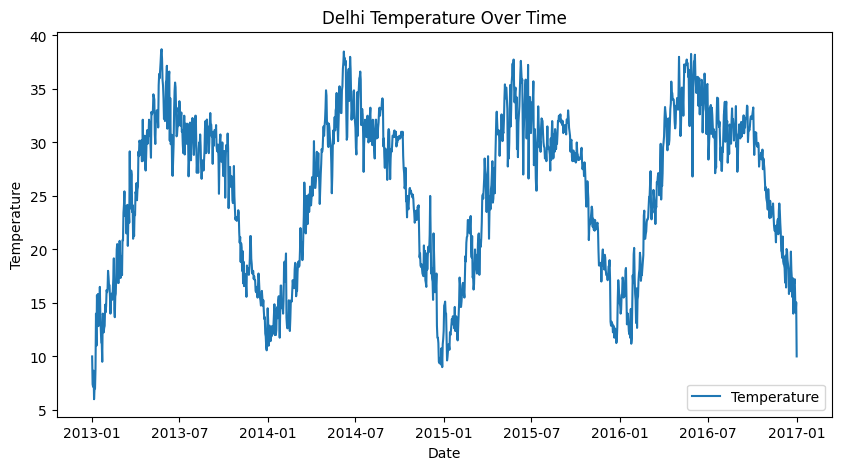

In [5]:
plt.figure(figsize=(10,5))
plt.plot(df['Temperature'], label='Temperature')
plt.title("Delhi Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.show()

In [6]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Temperature']])

In [7]:
def create_dataset(data, time_step=30):
    X, y = [], []

    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])

    return np.array(X), np.array(y)

time_step = 30
X, y = create_dataset(scaled_data, time_step)

print(X.shape, y.shape)

(1432, 30, 1) (1432, 1)


In [8]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [9]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0435 - val_loss: 0.0067
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0067 - val_loss: 0.0053
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0057 - val_loss: 0.0047
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0054 - val_loss: 0.0046
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0052 - val_loss: 0.0043
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0050 - val_loss: 0.0046
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0047 - val_loss: 0.0040
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0049 - val_loss: 0.0046
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0048 - val_loss: 0.0039
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0044 - val_loss: 0.0039
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0044 - val_loss: 0.0046
Epoch 12/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0

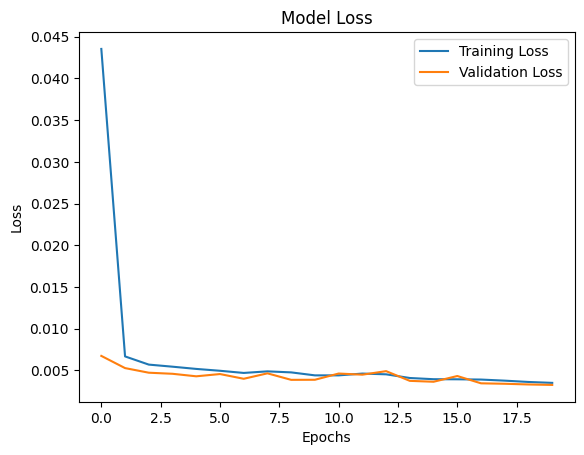

In [11]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [12]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Convert back to original values
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

y_train_actual = scaler.inverse_transform(y_train)
y_test_actual = scaler.inverse_transform(y_test)

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


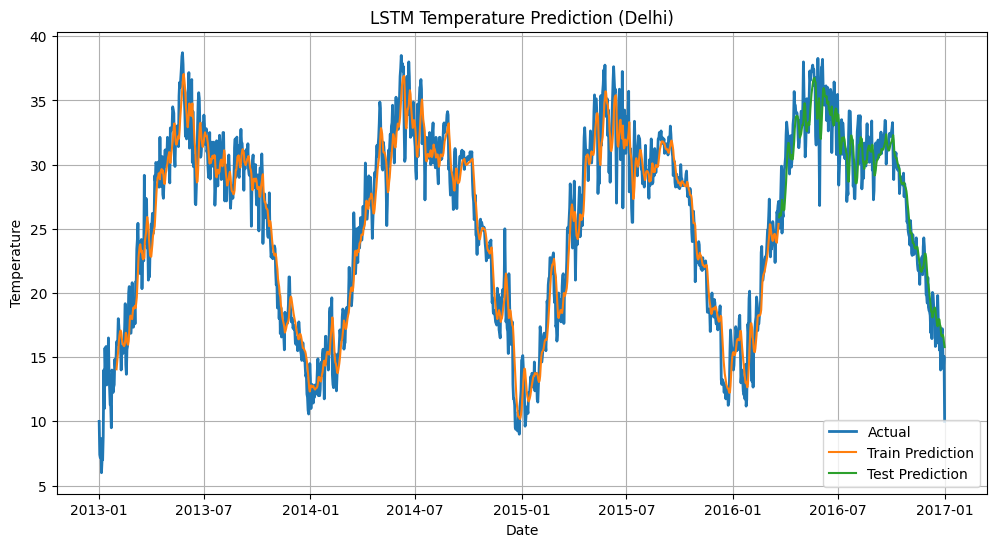

In [17]:
plt.figure(figsize=(12,6))

# Plot actual data
plt.plot(df.index, df['Temperature'], label='Actual', linewidth=2)

# Train prediction index
train_dates = df.index[time_step: time_step + len(train_predict)]

# Test prediction index
test_dates = df.index[time_step + len(train_predict): time_step + len(train_predict) + len(test_predict)]

# Plot predictions
plt.plot(train_dates, train_predict, label='Train Prediction')
plt.plot(test_dates, test_predict, label='Test Prediction')

plt.title("LSTM Temperature Prediction (Delhi)")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.grid()

plt.show()

In [14]:
future_steps = 7
last_data = scaled_data[-time_step:]

future_predictions = []

for _ in range(future_steps):
    pred = model.predict(last_data.reshape(1, time_step, 1))
    future_predictions.append(pred[0][0])

    last_data = np.append(last_data[1:], pred, axis=0)

# Convert back to original scale
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

print("Next 7 Days Temperature Prediction:")
print(future_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Next 7 Days Temperature Prediction:
[[14.757372]
 [14.419604]
 [14.278793]
 [14.233849]
 [14.236762]
 [14.264169]
 [14.303491]]


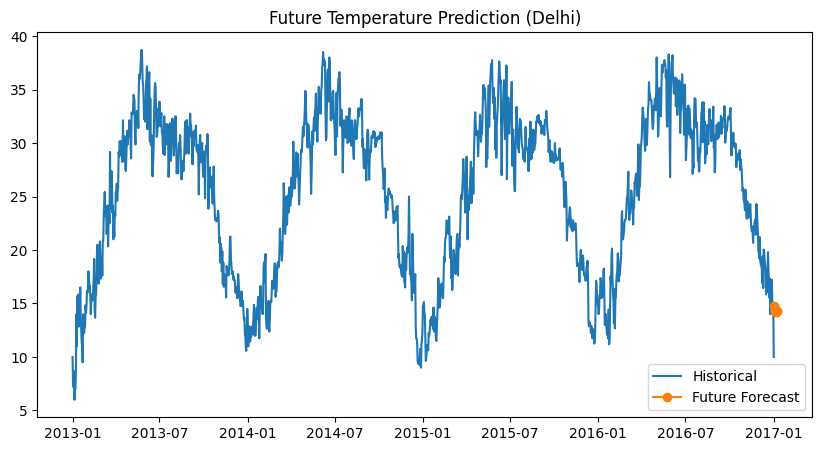

In [15]:
future_dates = pd.date_range(
    start=df.index[-1],
    periods=future_steps+1,
    freq='D'
)[1:]

plt.figure(figsize=(10,5))

plt.plot(df.index, df['Temperature'], label='Historical')
plt.plot(future_dates, future_predictions, label='Future Forecast', marker='o')

plt.title("Future Temperature Prediction (Delhi)")
plt.legend()
plt.show()